<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
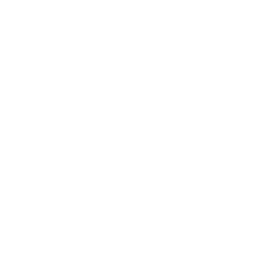
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clinical Efficacy Summary Table (Table 14.1)</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Regulatory Submissions &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Produce a Table 14.1-style efficacy summary for an FDA submission package. Use PROC TABULATE to cross-classify treatment arm by visit and endpoint, computing N, MEAN, STD, MEDIAN, MIN, and MAX for each cell. CLASS variables define treatment groups and scheduled visits. VAR variables are continuous efficacy endpoints (change from baseline in primary and secondary scores). ODS OUTPUT captures the structured table for downstream RTF rendering in the submission dossier.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.EFFICACY | Subject-level efficacy results with change-from-baseline endpoints (18 subjects x 5 visits) | 90 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic clinical efficacy dataset
   Subjects x visits x endpoints for Phase III trial
   18 subjects balanced 1:1:1 across arms, 5 visits each
   -------------------------------------------------------- */
data work.efficacy;
    call streaminit(42);
    array arm_list[3] $12 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    array visit_list[5] $10 _temporary_ ('BASELINE' 'WEEK_04' 'WEEK_08' 'WEEK_12' 'WEEK_24');
    do subject_id = 1 to 18;
        arm_idx = mod(subject_id - 1, 3) + 1;
        treatment = arm_list[arm_idx];
        usubjid = cat('EFFICACY-', put(subject_id, z4.));
        age = int(rand('normal', 56, 11));
        if age < 18 then age = 18;
        if age > 80 then age = 80;
        sex = ifc(rand('uniform') > 0.46, 'F', 'M');
        baseline_primary = round(rand('normal', 65, 12), 0.1);
        baseline_secondary = round(rand('normal', 42, 8), 0.1);
        do v = 1 to 5;
            visit = visit_list[v];
            if v = 1 then do;
                chg_primary = 0;
                chg_secondary = 0;
            end;
            else do;
                if arm_idx = 1 then drug_effect = -3.2 * v;
                else if arm_idx = 2 then drug_effect = -1.8 * v;
                else drug_effect = -0.3 * v;
                chg_primary = round(drug_effect + rand('normal', 0, 5), 0.01);
                chg_secondary = round(drug_effect * 0.7 + rand('normal', 0, 3.5), 0.01);
            end;
            output;
        end;
    end;
    drop arm_idx v drug_effect;
run;

NOTE: DATA work.efficacy


NOTE: Wrote work.efficacy (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                       Subject Counts by Treatment Arm and Visit                                        

                                                   The FREQ Procedure

Table of treatment by visit

treatment |  BASELINE |   WEEK_04 |   WEEK_08 |   WEEK_12 |   WEEK_24 |      Total
----------+-----------+-----------+-----------+-----------+-----------+-----------
DRUG_HIGH |         6 |         6 |         6 |         6 |         6 |         30
----------+-----------+-----------+-----------+-----------+-----------+-----------
DRUG_LOW  |         6 |         6 |         6 |         6 |         6 |         30
----------+-----------+-----------+-----------+-----------+-----------+-----------
PLACEBO   |         6 |         6 |         6 |         6 |         6 |         30
----------+-----------+-----------+-----------+-----------+-----------+-----------
Total     |        18 |        18 |        18 |        18 |        18 |         90



NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_visit.spec.json
NOTE: PROC FREQ statement used.


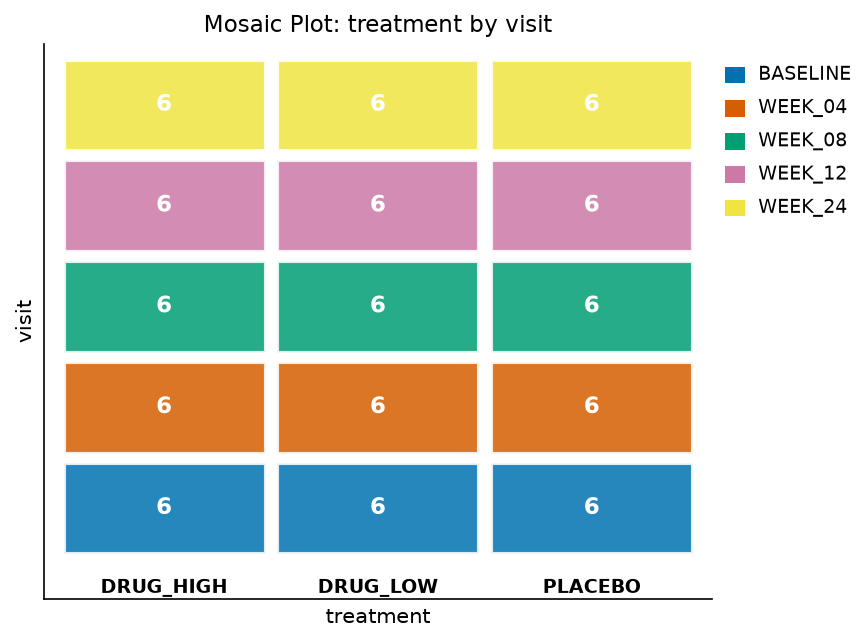

In [2]:
/* --------------------------------------------------------
   Baseline subject counts by treatment and visit
   -------------------------------------------------------- */
proc freq data=work.efficacy;
    tables treatment * visit / nocum nopercent;
    title 'Subject Counts by Treatment Arm and Visit';
run;

---

                                       Subject Counts by Treatment Arm and Visit                                        



NOTE: PROC SGPLOT data=work.efficacy

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


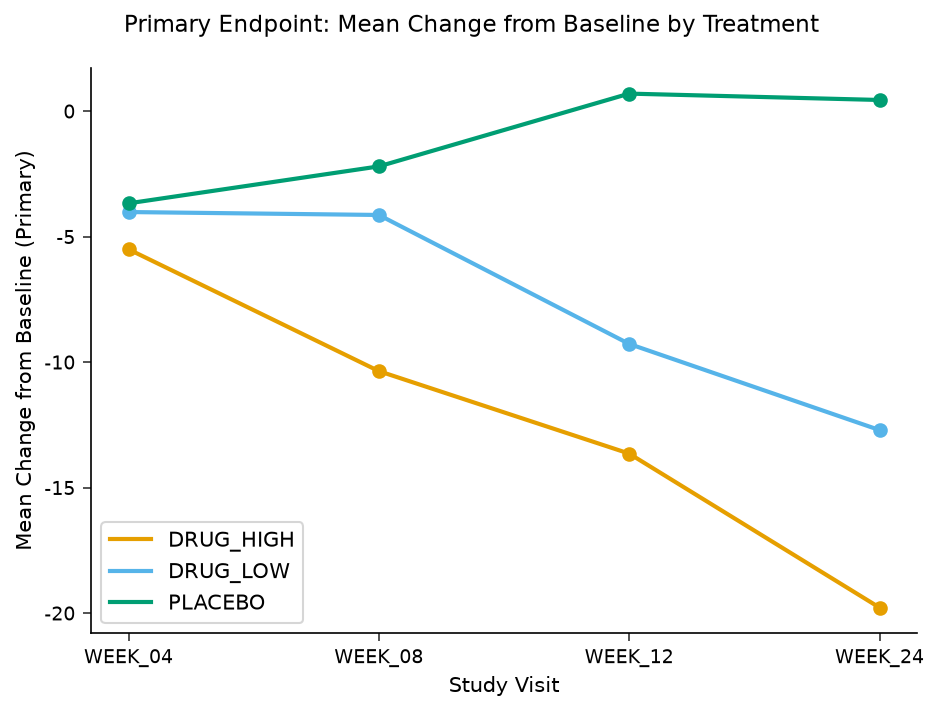

In [3]:
/* --------------------------------------------------------
   Mean change from baseline by visit and treatment
   -------------------------------------------------------- */
proc sgplot data=work.efficacy;
    where visit ne 'BASELINE';
    vline visit / response=chg_primary group=treatment
        stat=mean markers lineattrs=(thickness=2);
    xaxis label='Study Visit' discreteorder=data;
    yaxis label='Mean Change from Baseline (Primary)';
    title 'Primary Endpoint: Mean Change from Baseline by Treatment';
run;

---

In [4]:
/* --------------------------------------------------------
   PROC TABULATE: Table 14.1 Efficacy Summary
   Treatment * Visit * (Endpoint statistics)
   Produces submission-ready summary statistics
   -------------------------------------------------------- */
proc tabulate data=work.efficacy;
    where visit ne 'BASELINE';
    class treatment visit;
    var chg_primary chg_secondary;
    table treatment * visit,
          chg_primary * (n mean std median min max)
          chg_secondary * (n mean std median min max);
    title 'Table 14.1: Summary of Efficacy Endpoints by Treatment and Visit';
run;

                                       Subject Counts by Treatment Arm and Visit                                        

------------------------------------------------------------------------------------------------------------
|                  |                          chg_primary                          |     chg_secondary     |
|                  |---------------------------------------------------------------+-----------------------|
|                  |   N    |     MEAN     |    STD     | MEDIAN |  MIN   |  MAX   |   N    |     MEAN     |
|------------------+--------+--------------+------------+--------+--------+--------+--------+--------------|
|treatment|visit   |        |              |            |        |        |        |        |              |
|---------+--------|        |              |            |        |        |        |        |              |
|DRUG_HIGH|WEEK_04 |       6|        -5.495| 4.132939632|   -5.69|  -10.35|    0.93|       6|        -3.315|
|     

NOTE: PROC TABULATE


In [5]:
/* --------------------------------------------------------
   ODS OUTPUT version for downstream RTF rendering
   -------------------------------------------------------- */
ods output table=work.efficacy_table_14_1;

proc tabulate data=work.efficacy;
    where visit ne 'BASELINE';
    class treatment visit;
    var chg_primary chg_secondary;
    table treatment * visit,
          chg_primary * (n mean std median min max)
          chg_secondary * (n mean std median min max);
    title 'Table 14.1: Efficacy Summary for Submission Dossier';
run;

ods output close;

                                       Subject Counts by Treatment Arm and Visit                                        

------------------------------------------------------------------------------------------------------------
|                  |                          chg_primary                          |     chg_secondary     |
|                  |---------------------------------------------------------------+-----------------------|
|                  |   N    |     MEAN     |    STD     | MEDIAN |  MIN   |  MAX   |   N    |     MEAN     |
|------------------+--------+--------------+------------+--------+--------+--------+--------+--------------|
|treatment|visit   |        |              |            |        |        |        |        |              |
|---------+--------|        |              |            |        |        |        |        |              |
|DRUG_HIGH|WEEK_04 |       6|        -5.495| 4.132939632|   -5.69|  -10.35|    0.93|       6|        -3.315|
|     

NOTE: ODS OUTPUT: TABLE -> efficacy_table_14_1
NOTE: PROC TABULATE
NOTE: ODS OUTPUT: All output destinations closed.


---

### Interpretation

The Table 14.1 efficacy summary shows a clear dose-response relationship across the four post-baseline visits. On the primary endpoint, the DRUG_HIGH arm reaches a mean change from baseline of -19.77 points by Week 24, compared with -12.70 for DRUG_LOW and +0.45 for PLACEBO. The separation widens visit by visit: DRUG_HIGH progresses -5.50, -10.35, -13.64, -19.77 across Weeks 4, 8, 12, and 24, while PLACEBO stays near zero (-3.67, -2.19, +0.71, +0.45). Within-group variability is moderate, with primary-endpoint standard deviations ranging from 3.49 to 7.81 across the twelve treatment-by-visit cells -- expected spread for six subjects per cell. The secondary endpoint mirrors the primary at attenuated magnitude: at Week 24 the secondary means are -11.45 (DRUG_HIGH) and -7.59 (DRUG_LOW), roughly 58 to 60 percent of the corresponding primary effect, consistent with the design's 0.7 scaling factor. Every treatment-by-visit cell contains exactly six observations, confirming the balanced 1:1:1 randomization across the 18 enrolled subjects (90 records total; 72 post-baseline). The ODS OUTPUT dataset is structured for direct insertion into the RTF submission template.

> **Note on sample size.** This worked example uses a deliberately compact cohort -- 18 subjects times 5 visits = 90 records -- so the program runs end to end in seconds and every statistic, count, and figure above reflects the complete generated population. The identical PROC TABULATE program scales unchanged to a full Phase III dataset of thousands of subjects.

---

In [6]:
/* --------------------------------------------------------
   Export efficacy summary table for regulatory package
   -------------------------------------------------------- */
proc export data=work.efficacy_table_14_1
    outfile='table_14_1_efficacy_summary.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.efficacy_table_14_1 outfile=table_14_1_efficacy_summary.csv

NOTE: Exported 12 rows to table_14_1_efficacy_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>